In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
functional_zones = gpd.read_file("../data/blocksnet/functional_zones.geojson")
functional_zones

,functional_zone,geometry
0,Т1Ж2-2,"MULTIPOLYGON (((30.29128 60.05713, 30.29105 60..."
1,Т1Ж2-2,"MULTIPOLYGON (((30.22172 60.10549, 30.2211 60...."
2,Т1Ж2-2,"MULTIPOLYGON (((30.26445 60.07791, 30.26417 60..."
3,Т1Ж2-2,"MULTIPOLYGON (((30.23424 60.11373, 30.23378 60..."
4,Т1Ж2-2,"MULTIPOLYGON (((30.30896 60.05272, 30.30931 60..."
...,...,...
7268,ТС1,"MULTIPOLYGON (((30.43977 59.6719, 30.43974 59...."
7269,ТС1,"MULTIPOLYGON (((30.44419 59.67214, 30.44314 59..."
7270,ТС1,"MULTIPOLYGON (((30.19126 59.81696, 30.20195 59..."
7271,ТС2,"MULTIPOLYGON (((30.19126 59.81556, 30.19138 59..."


In [3]:
cadastr_blocks = gpd.read_parquet('../data/traning_data/spb_bloks_price_train.parquet')
cadastr_blocks = cadastr_blocks.to_crs(epsg=32636)
cadastr_blocks

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry
0,78,"Санкт-Петербург, город Зеленогорск, Решетников...",10833260.98,5846.3362,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1852.0,"POLYGON ((317291.404 6682705.747, 317290.757 6..."
1,78,"г.Санкт-Петербург, город Зеленогорск, Решетник...",6533139.72,5444.2831,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1200.0,"POLYGON ((317543.277 6682951.554, 317540.108 6..."
2,78,"Санкт-Петербург, город Зеленогорск, Красавица,...",16395.97,1366.3305,Земли населенных пунктов,Для размещения объектов коммунального хозяйства,12.0,"POLYGON ((320176.93 6682616.683, 320174.372 66..."
3,78,"Санкт-Петербург, город Зеленогорск, Решетников...",8425371.37,5513.9865,Земли населенных пунктов,Для размещения индивидуального (одноквартирног...,1528.0,"POLYGON ((317419.986 6683190.666, 317422.517 6..."
4,78,"Санкт-Петербург, город Зеленогорск, Решетников...",11430710.60,5715.3553,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,2000.0,"POLYGON ((317516.96 6682722.073, 317513.475 66..."
...,...,...,...,...,...,...,...,...
136534,78,"Санкт-Петербург, город Павловск, садоводство ""...",2177378.29,3114.9904,Земли населенных пунктов,для садоводства,699.0,"POLYGON ((357257.416 6614561.752, 357270.551 6..."
136535,78,"Санкт-Петербург, город Павловск, садоводство ""...",2211847.66,3115.2784,Земли населенных пунктов,для садоводства,710.0,"POLYGON ((357190.1 6614444.913, 357174.643 661..."
136536,78,"Санкт-Петербург, город Павловск, садоводство ""...",2227101.45,3114.8272,Земли населенных пунктов,для садоводства,715.0,"POLYGON ((357293.194 6614548.394, 357313.685 6..."
136537,78,"Санкт-Петербург, город Павловск, садоводство ""...",2074858.38,3110.7322,Земли населенных пунктов,для садоводства,667.0,"POLYGON ((357203.693 6614603.655, 357218.9 661..."


In [4]:
import pandas as pd
import geopandas as gpd


def postprocess_urban_blocks_keep_attrs(blocks: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if not isinstance(blocks, gpd.GeoDataFrame):
        raise ValueError("An instance of GeoDataFrame must be provided")
    if len(blocks) == 0:
        raise ValueError("Rows count must be greater than 0")

    blocks = blocks.copy()

    valid_blocks = blocks[blocks.is_valid].copy()
    invalid_blocks = blocks[~blocks.is_valid].copy()

    if not invalid_blocks.empty:
        invalid_blocks["geometry"] = invalid_blocks.geometry.make_valid()

    blocks = gpd.GeoDataFrame(
        pd.concat([valid_blocks, invalid_blocks], ignore_index=True),
        crs=blocks.crs,
    )

    blocks = blocks.explode(index_parts=False).reset_index(drop=True)
    blocks = blocks[blocks.geom_type == "Polygon"].copy()
    blocks = blocks[~blocks.geometry.is_empty].copy()
    blocks = blocks.reset_index(drop=True)

    return blocks


cadastr_blocks = postprocess_urban_blocks_keep_attrs(cadastr_blocks)
cadastr_blocks

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry
0,78,"Санкт-Петербург, город Зеленогорск, Решетников...",1.083326e+07,5846.3362,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1852.0,"POLYGON ((317291.404 6682705.747, 317290.757 6..."
1,78,"г.Санкт-Петербург, город Зеленогорск, Решетник...",6.533140e+06,5444.2831,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1200.0,"POLYGON ((317543.277 6682951.554, 317540.108 6..."
2,78,"Санкт-Петербург, город Зеленогорск, Красавица,...",1.639597e+04,1366.3305,Земли населенных пунктов,Для размещения объектов коммунального хозяйства,12.0,"POLYGON ((320176.93 6682616.683, 320174.372 66..."
3,78,"Санкт-Петербург, город Зеленогорск, Решетников...",8.425371e+06,5513.9865,Земли населенных пунктов,Для размещения индивидуального (одноквартирног...,1528.0,"POLYGON ((317419.986 6683190.666, 317422.517 6..."
4,78,"Санкт-Петербург, город Зеленогорск, Решетников...",1.143071e+07,5715.3553,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,2000.0,"POLYGON ((317516.96 6682722.073, 317513.475 66..."
...,...,...,...,...,...,...,...,...
138486,78,"Санкт-Петербург, г. Пушкин, тер. Земли СПГАУ, ...",6.840462e+08,723.9986,Земли населенных пунктов,для сельскохозяйственного использования,944817.0,"POLYGON ((353520.346 6626088.959, 353520.265 6..."
138487,78,"Санкт-Петербург, г. Пушкин, тер. Земли СПГАУ, ...",6.840462e+08,723.9986,Земли населенных пунктов,для сельскохозяйственного использования,944817.0,"POLYGON ((353522.35 6626087.016, 353522.35 662..."
138488,78,"Санкт-Петербург, г. Пушкин, тер. Земли СПГАУ, ...",6.840462e+08,723.9986,Земли населенных пунктов,для сельскохозяйственного использования,944817.0,"POLYGON ((353537.11 6626178.93, 353535.347 662..."
138489,78,"Санкт-Петербург, г. Пушкин, тер. Земли СПГАУ, ...",6.840462e+08,723.9986,Земли населенных пунктов,для сельскохозяйственного использования,944817.0,"POLYGON ((354668.135 6626424.275, 354666.825 6..."


In [5]:
# from blocksnet.blocks.postprocessing import postprocess_urban_blocks
# cadastr_geometry = postprocess_urban_blocks(cadastr_blocks)
# cadastr_geometry

In [6]:
cadastr_blocks['log_cost_index'] = np.log1p(cadastr_blocks['cost_index'])

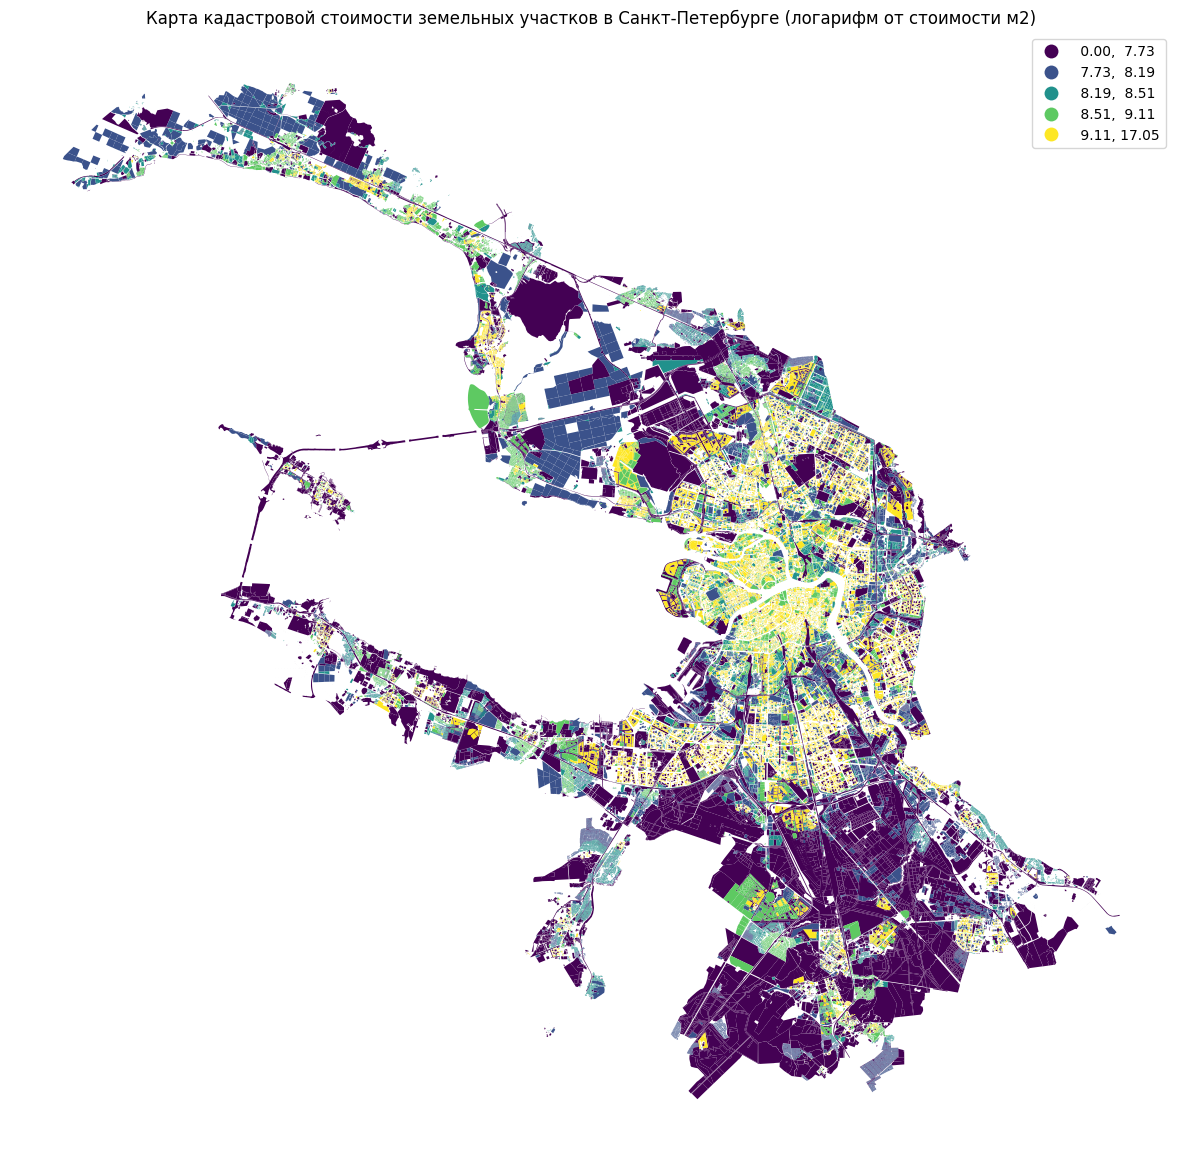

In [7]:
# Картируем лог-цену
cadastr_blocks.plot(
    column='log_cost_index',
    scheme='quantiles',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()
plt.title('Карта кадастровой стоимости земельных участков в Санкт-Петербурге (логарифм от стоимости м2)')

plt.show()

# Назначение функциональных зон

In [8]:
functional_zones = functional_zones.to_crs(epsg=32636)

In [9]:

from blocksnet.blocks.assignment import assign_objects

objects_gdf = assign_objects(cadastr_blocks, functional_zones.rename(columns={'functional_zone': 'name'}))
objects_gdf.head()

,geometry,Т1Ж2-2,Т2Ж1,Т3Ж1,Т3Ж2,ТУ,ТИ2,ТИ3,ТД1-2,ТД2,...,ТР1,ТР4,ТР5-1,ТР5-2,ТК1,ТК2,ТС2,ТК3,name,share
0,"POLYGON ((317291.404 6682705.747, 317290.757 6...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Т1Ж2-2,1.0
1,"POLYGON ((317543.277 6682951.554, 317540.108 6...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Т1Ж2-2,1.0
2,"POLYGON ((320176.93 6682616.683, 320174.372 66...",0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Т2Ж1,1.0
3,"POLYGON ((317419.986 6683190.666, 317422.517 6...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Т1Ж2-2,1.0
4,"POLYGON ((317516.96 6682722.073, 317513.475 66...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Т1Ж2-2,1.0


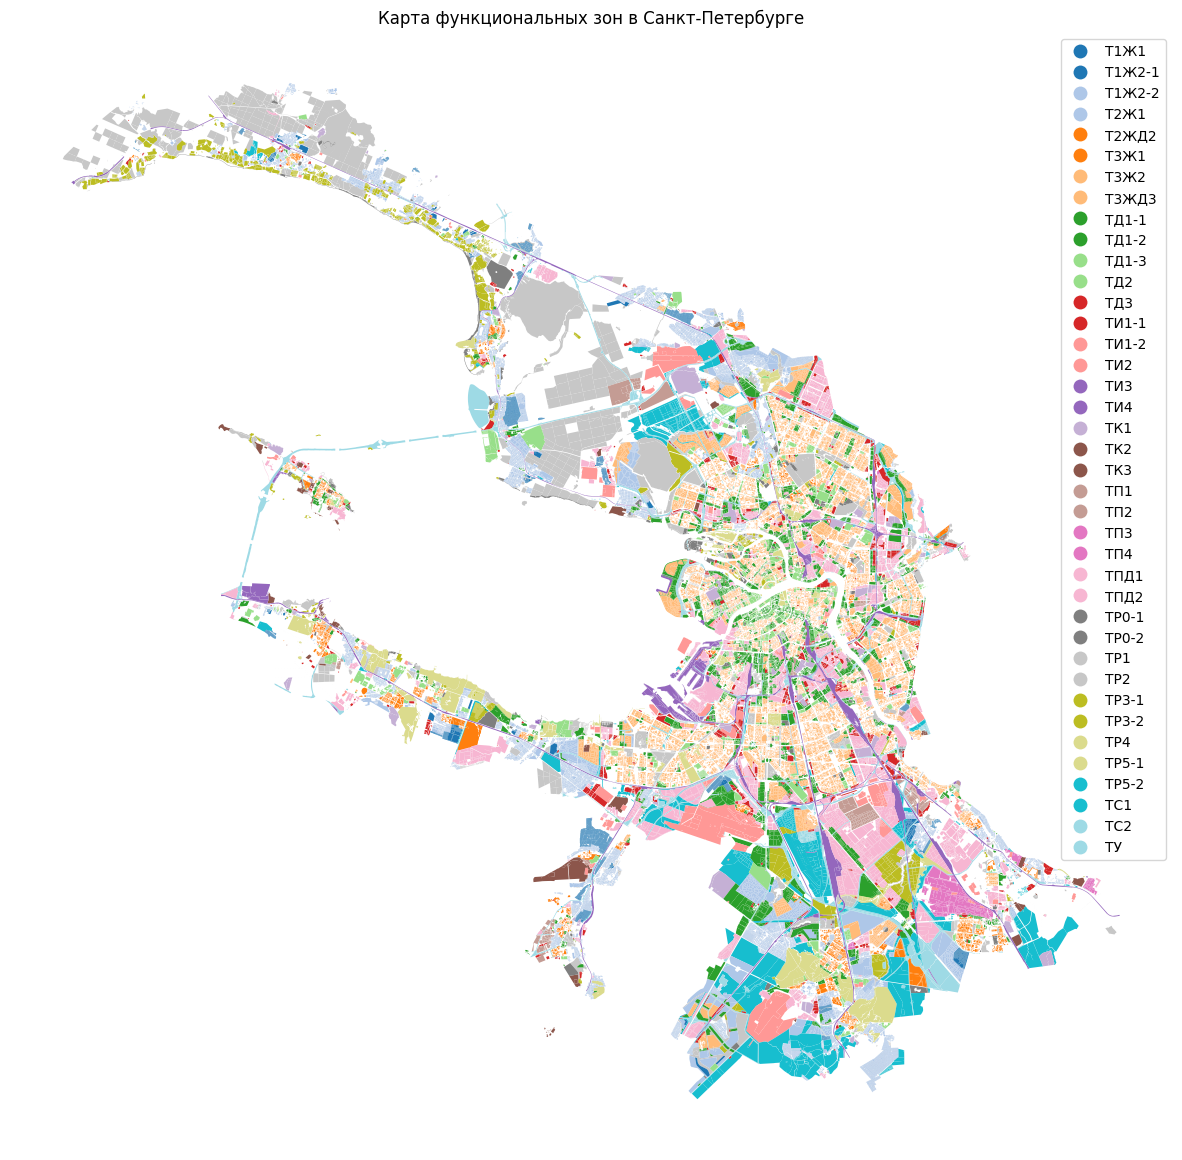

In [10]:
objects_gdf.plot(
    column='name',
    figsize=(15,15),
    legend=True,
    cmap='tab20'
).set_axis_off()
plt.title('Карта функциональных зон в Санкт-Петербурге')
plt.show()

In [11]:
from blocksnet.enums import LandUse

rules = {
    "Т3Ж1": LandUse.RESIDENTIAL,
    "ТР0-2": LandUse.RECREATION,
    "Т3Ж2": LandUse.RESIDENTIAL,
    "Т1Ж2-1": LandUse.RESIDENTIAL,
    "Т2ЖД2": LandUse.RESIDENTIAL,
    "ТД1-3": LandUse.BUSINESS,
    "ТД2": LandUse.BUSINESS,
    "ТД3": LandUse.BUSINESS,
    "ТУ": LandUse.TRANSPORT,
    "ТИ4": LandUse.TRANSPORT,
    "ТД1-1": LandUse.RESIDENTIAL,
    "ТД1-2": LandUse.RESIDENTIAL,
    "ТПД1": LandUse.INDUSTRIAL,
    "ТПД2": LandUse.INDUSTRIAL,
    "ТИ1-1": LandUse.TRANSPORT,
    "Т3ЖД3": LandUse.RESIDENTIAL,
    "ТК1": LandUse.SPECIAL,
    "ТР2": LandUse.RECREATION,
    "ТИ2": LandUse.TRANSPORT,
    "ТР5-2": LandUse.RECREATION,
    "Т1Ж2-2": LandUse.RESIDENTIAL,
    "ТР4": LandUse.RECREATION,
    "ТР5-1": LandUse.RECREATION,
    "Т2Ж1": LandUse.RESIDENTIAL,
    "ТИ3": LandUse.TRANSPORT,
    "Т1Ж1": LandUse.RESIDENTIAL,
    "ТИ1-2": LandUse.TRANSPORT,
    "ТР3-2": LandUse.RECREATION,
    "ТР0-1": LandUse.RECREATION,
    "ТП2": LandUse.INDUSTRIAL,
    "ТК3": LandUse.SPECIAL,
    "ТР1": LandUse.RECREATION,
    "ТР3-1": LandUse.RECREATION,
    "ТС1": LandUse.AGRICULTURE,
    "ТК2": LandUse.SPECIAL,
    "ТП1": LandUse.INDUSTRIAL,
    "ТП3": LandUse.INDUSTRIAL,
    "ТП4": LandUse.INDUSTRIAL,
    "ТС2": LandUse.SPECIAL,
}

In [12]:
import math

math.ceil(1/1000*16)

1

In [13]:
from blocksnet.blocks.assignment import assign_land_use

land_use_gdf = assign_land_use(cadastr_blocks, functional_zones, rules)
land_use_gdf.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((317291.404 6682705.747, 317290.757 6...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,LandUse.RESIDENTIAL,1.0
1,"POLYGON ((317543.277 6682951.554, 317540.108 6...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,LandUse.RESIDENTIAL,1.0
2,"POLYGON ((320176.93 6682616.683, 320174.372 66...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,LandUse.RESIDENTIAL,1.0
3,"POLYGON ((317419.986 6683190.666, 317422.517 6...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,LandUse.RESIDENTIAL,1.0
4,"POLYGON ((317516.96 6682722.073, 317513.475 66...",1.0,0.0,0.0,0.0,0.0,0.0,0.0,LandUse.RESIDENTIAL,1.0


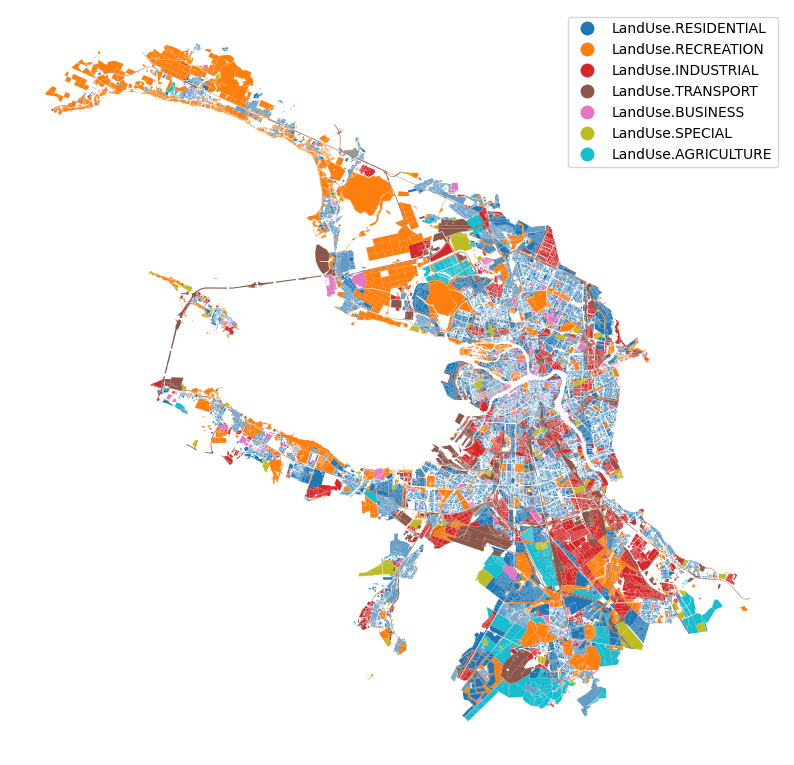

In [14]:
land_use_gdf.plot(column='land_use', legend=True, figsize=(10,10)).set_axis_off()

In [15]:
cadastr_blocks = cadastr_blocks.join(land_use_gdf.drop(columns=['geometry']))
cadastr_blocks.head()


,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,log_cost_index,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,78,"Санкт-Петербург, город Зеленогорск, Решетников...",10833260.98,5846.3362,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1852.0,"POLYGON ((317291.404 6682705.747, 317290.757 6...",8.673741,1.0,0.0,0.0,0.0,0.0,0.0,0.0,LandUse.RESIDENTIAL,1.0
1,78,"г.Санкт-Петербург, город Зеленогорск, Решетник...",6533139.72,5444.2831,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1200.0,"POLYGON ((317543.277 6682951.554, 317540.108 6...",8.602505,1.0,0.0,0.0,0.0,0.0,0.0,0.0,LandUse.RESIDENTIAL,1.0
2,78,"Санкт-Петербург, город Зеленогорск, Красавица,...",16395.97,1366.3305,Земли населенных пунктов,Для размещения объектов коммунального хозяйства,12.0,"POLYGON ((320176.93 6682616.683, 320174.372 66...",7.220616,1.0,0.0,0.0,0.0,0.0,0.0,0.0,LandUse.RESIDENTIAL,1.0
3,78,"Санкт-Петербург, город Зеленогорск, Решетников...",8425371.37,5513.9865,Земли населенных пунктов,Для размещения индивидуального (одноквартирног...,1528.0,"POLYGON ((317419.986 6683190.666, 317422.517 6...",8.615224,1.0,0.0,0.0,0.0,0.0,0.0,0.0,LandUse.RESIDENTIAL,1.0
4,78,"Санкт-Петербург, город Зеленогорск, Решетников...",11430710.60,5715.3553,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,2000.0,"POLYGON ((317516.96 6682722.073, 317513.475 66...",8.651087,1.0,0.0,0.0,0.0,0.0,0.0,0.0,LandUse.RESIDENTIAL,1.0


# Назначение зданий

In [16]:
buildings = gpd.read_file("../data/blocksnet/buildings.geojson")
buildings = buildings.to_crs(epsg=32636)
buildings['number_of_floors'] = buildings['storeys_count'].clip(lower=1)
buildings['population'] = buildings['population_balanced']
buildings

,storeys_count,is_living,building_area,living_area,population_balanced,geometry,number_of_floors,population
0,1.0,True,95.155945,66.609161,0,"MULTIPOLYGON (((360058.761 6654864.061, 360055...",1.0,0
1,1.0,True,97.709000,68.396301,2,"MULTIPOLYGON (((359989.536 6654834.089, 359998...",1.0,2
2,1.0,True,93.291084,65.303757,1,"MULTIPOLYGON (((359963.356 6654739.755, 359960...",1.0,1
3,1.0,True,95.137489,66.596245,3,"MULTIPOLYGON (((359963.345 6654720.681, 359973...",1.0,3
4,1.0,True,94.628952,66.240265,1,"MULTIPOLYGON (((359979.747 6654704.844, 359989...",1.0,1
...,...,...,...,...,...,...,...,...
164726,1.0,False,158.061218,NaN,0,"MULTIPOLYGON (((325090.531 6643123.479, 325092...",1.0,0
164727,2.0,False,247.447449,NaN,0,"MULTIPOLYGON (((325149.985 6643143.947, 325154...",2.0,0
164728,NaN,False,117.635567,NaN,0,"MULTIPOLYGON (((324781.926 6643272.814, 324785...",NaN,0
164729,2.0,False,82.088295,NaN,0,"MULTIPOLYGON (((324870.756 6642890.349, 324875...",2.0,0


In [17]:
from blocksnet.preprocessing.imputing import impute_buildings
buildings = impute_buildings(buildings, default_living_demand=30)
buildings['number_of_floors'] = buildings['number_of_floors'].clip(lower=1)
buildings

2026-03-04 17:36:04.364 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column footprint_area not found and will be initialized as None
2026-03-04 17:36:04.364 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column build_floor_area not found and will be initialized as None
2026-03-04 17:36:04.365 | WARNING  | blocksnet.preprocessing.imputing.buildings.schemas:_before_validate:21 - Column non_living_area not found and will be initialized as None


,geometry,is_living,number_of_floors,footprint_area,build_floor_area,living_area,non_living_area,population
0,"MULTIPOLYGON (((360058.761 6654864.061, 360055...",True,1.0,95.125499,95.125499,66.609161,28.516337,2.0
1,"MULTIPOLYGON (((359989.536 6654834.089, 359998...",True,1.0,97.677776,97.677776,68.396301,29.281474,2.0
2,"MULTIPOLYGON (((359963.356 6654739.755, 359960...",True,1.0,93.261290,93.261290,65.303757,27.957533,1.0
3,"MULTIPOLYGON (((359963.345 6654720.681, 359973...",True,1.0,95.107108,95.107108,66.596245,28.510863,3.0
4,"MULTIPOLYGON (((359979.747 6654704.844, 359989...",True,1.0,94.598720,94.598720,66.240265,28.358455,1.0
...,...,...,...,...,...,...,...,...
164726,"MULTIPOLYGON (((325090.531 6643123.479, 325092...",False,1.0,158.053286,158.053286,0.000000,158.053286,0.0
164727,"MULTIPOLYGON (((325149.985 6643143.947, 325154...",False,2.0,247.434898,494.869796,0.000000,494.869796,0.0
164728,"MULTIPOLYGON (((324781.926 6643272.814, 324785...",False,1.0,117.629986,117.629986,0.000000,117.629986,0.0
164729,"MULTIPOLYGON (((324870.756 6642890.349, 324875...",False,2.0,82.084321,164.168641,0.000000,164.168641,0.0


In [18]:
from blocksnet.blocks.aggregation import aggregate_objects

buildings_blocks = aggregate_objects(cadastr_blocks, buildings)[0]

2026-03-04 17:36:04.594 | INFO     | blocksnet.blocks.aggregation.core:_preprocess_input:12 - Preprocessing input
2026-03-04 17:36:04.650 | INFO     | blocksnet.blocks.aggregation.core:aggregate_objects:41 - Aggregating objects


In [19]:
buildings_blocks

,geometry,is_living,number_of_floors,footprint_area,build_floor_area,living_area,non_living_area,population,count
0,"POLYGON ((317291.404 6682705.747, 317290.757 6...",2.0,3.0,217.343031,368.267626,257.782673,110.484954,8.0,2.0
1,"POLYGON ((317543.277 6682951.554, 317540.108 6...",1.0,1.0,77.848211,77.848211,54.492889,23.355322,3.0,1.0
2,"POLYGON ((320176.93 6682616.683, 320174.372 66...",0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
3,"POLYGON ((317419.986 6683190.666, 317422.517 6...",1.0,1.0,134.322388,134.322388,94.024094,40.298294,3.0,1.0
4,"POLYGON ((317516.96 6682722.073, 317513.475 66...",1.0,1.0,79.114847,79.114847,55.379520,23.735327,4.0,1.0
...,...,...,...,...,...,...,...,...,...
138486,"POLYGON ((353520.346 6626088.959, 353520.265 6...",2.0,3.0,70.814405,107.239373,75.088215,32.151158,3.0,2.0
138487,"POLYGON ((353522.35 6626087.016, 353522.35 662...",0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
138488,"POLYGON ((353537.11 6626178.93, 353535.347 662...",0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0
138489,"POLYGON ((354668.135 6626424.275, 354666.825 6...",0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0


In [20]:
cadastr_blocks = cadastr_blocks.join(buildings_blocks.drop(columns=['geometry']))

# Морфотипы 

In [21]:
from blocksnet.analysis.indicators import calculate_density_indicators

cadastr_blocks['site_area'] = cadastr_blocks['specified_area']
density_input = cadastr_blocks[
    ['site_area', 'footprint_area', 'build_floor_area', 'living_area']
].copy()

density_input = density_input.dropna(subset=['site_area', 'footprint_area', 'build_floor_area', 'living_area'])

density_input['non_living_area'] = (
    density_input['build_floor_area'] - density_input['living_area']
).clip(lower=0)

density_df = calculate_density_indicators(density_input)
density_df


,site_area,footprint_area,build_floor_area,living_area,non_living_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,1852.0,217.343031,368.267626,257.782673,110.484954,0.198849,0.117356,0.699987,1.694407,4.438775e+00,1.186064,0.508344
1,1200.0,77.848211,77.848211,54.492889,23.355322,0.064874,0.064874,0.699989,1.000000,1.441461e+01,0.699989,0.300011
2,12.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
3,1528.0,134.322388,134.322388,94.024094,40.298294,0.087907,0.087907,0.699988,1.000000,1.037562e+01,0.699988,0.300012
4,2000.0,79.114847,79.114847,55.379520,23.735327,0.039557,0.039557,0.699989,1.000000,2.427970e+01,0.699989,0.300011
...,...,...,...,...,...,...,...,...,...,...,...,...
138486,944817.0,70.814405,107.239373,75.088215,32.151158,0.000114,0.000075,0.700193,1.514372,8.809695e+03,1.060352,0.454020
138487,944817.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
138488,944817.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
138489,944817.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,inf,NaN,NaN


In [22]:
cadastr_blocks.loc[:, density_df.columns] = density_df
cadastr_blocks.head()

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,log_cost_index,residential,...,population,count,site_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,78,"Санкт-Петербург, город Зеленогорск, Решетников...",10833260.98,5846.3362,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1852.0,"POLYGON ((317291.404 6682705.747, 317290.757 6...",8.673741,1.0,...,8.0,2.0,1852.0,0.198849,0.117356,0.699987,1.694407,4.438775,1.186064,0.508344
1,78,"г.Санкт-Петербург, город Зеленогорск, Решетник...",6533139.72,5444.2831,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1200.0,"POLYGON ((317543.277 6682951.554, 317540.108 6...",8.602505,1.0,...,3.0,1.0,1200.0,0.064874,0.064874,0.699989,1.000000,14.414612,0.699989,0.300011
2,78,"Санкт-Петербург, город Зеленогорск, Красавица,...",16395.97,1366.3305,Земли населенных пунктов,Для размещения объектов коммунального хозяйства,12.0,"POLYGON ((320176.93 6682616.683, 320174.372 66...",7.220616,1.0,...,0.0,0.0,12.0,0.000000,0.000000,NaN,NaN,inf,NaN,NaN
3,78,"Санкт-Петербург, город Зеленогорск, Решетников...",8425371.37,5513.9865,Земли населенных пунктов,Для размещения индивидуального (одноквартирног...,1528.0,"POLYGON ((317419.986 6683190.666, 317422.517 6...",8.615224,1.0,...,3.0,1.0,1528.0,0.087907,0.087907,0.699988,1.000000,10.375617,0.699988,0.300012
4,78,"Санкт-Петербург, город Зеленогорск, Решетников...",11430710.60,5715.3553,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,2000.0,"POLYGON ((317516.96 6682722.073, 317513.475 66...",8.651087,1.0,...,4.0,1.0,2000.0,0.039557,0.039557,0.699989,1.000000,24.279705,0.699989,0.300011


In [23]:
from blocksnet.analysis.morphotypes import get_strelka_morphotypes


blocks_df = get_strelka_morphotypes(cadastr_blocks)
blocks_df.head()

,l,fsi,mxi,morphotype
0,1.694407,0.198849,0.699987,low-rise model
1,1.000000,0.064874,0.699989,individual residential
2,0.000000,0.000000,0.000000,NaN
3,1.000000,0.087907,0.699988,individual residential
4,1.000000,0.039557,0.699989,individual residential


In [24]:
cadastr_blocks.loc[:, blocks_df.columns] = blocks_df
cadastr_blocks.head()

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,log_cost_index,residential,...,count,site_area,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype
0,78,"Санкт-Петербург, город Зеленогорск, Решетников...",10833260.98,5846.3362,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1852.0,"POLYGON ((317291.404 6682705.747, 317290.757 6...",8.673741,1.0,...,2.0,1852.0,0.198849,0.117356,0.699987,1.694407,4.438775,1.186064,0.508344,low-rise model
1,78,"г.Санкт-Петербург, город Зеленогорск, Решетник...",6533139.72,5444.2831,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1200.0,"POLYGON ((317543.277 6682951.554, 317540.108 6...",8.602505,1.0,...,1.0,1200.0,0.064874,0.064874,0.699989,1.000000,14.414612,0.699989,0.300011,individual residential
2,78,"Санкт-Петербург, город Зеленогорск, Красавица,...",16395.97,1366.3305,Земли населенных пунктов,Для размещения объектов коммунального хозяйства,12.0,"POLYGON ((320176.93 6682616.683, 320174.372 66...",7.220616,1.0,...,0.0,12.0,0.000000,0.000000,0.000000,0.000000,inf,NaN,NaN,NaN
3,78,"Санкт-Петербург, город Зеленогорск, Решетников...",8425371.37,5513.9865,Земли населенных пунктов,Для размещения индивидуального (одноквартирног...,1528.0,"POLYGON ((317419.986 6683190.666, 317422.517 6...",8.615224,1.0,...,1.0,1528.0,0.087907,0.087907,0.699988,1.000000,10.375617,0.699988,0.300012,individual residential
4,78,"Санкт-Петербург, город Зеленогорск, Решетников...",11430710.60,5715.3553,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,2000.0,"POLYGON ((317516.96 6682722.073, 317513.475 66...",8.651087,1.0,...,1.0,2000.0,0.039557,0.039557,0.699989,1.000000,24.279705,0.699989,0.300011,individual residential


# Связанность

In [25]:
import numpy as np
import pandas as pd
import geopandas as gpd

from urbanomy.methods.land_value_modeling.constants import ACCESSIBILITY_SPEED


def calculate_area_accessibility_grid_approx(
    blocks: gpd.GeoDataFrame,
    site_area_col: str = "site_area",
    grid_size: float = 500.0,
    chunk_size: int = 2048,
) -> pd.DataFrame:
    if not isinstance(blocks, gpd.GeoDataFrame):
        raise ValueError("blocks must be a GeoDataFrame")
    if blocks.empty:
        return pd.DataFrame(index=blocks.index, columns=["area_accessibility"], dtype=float)
    if site_area_col not in blocks.columns:
        raise ValueError(f"Column '{site_area_col}' not found")
    if blocks.crs is None:
        raise ValueError("GeoDataFrame CRS is None")

    utm_crs = blocks.estimate_utm_crs()
    work = blocks.to_crs(utm_crs) if utm_crs else blocks.copy()

    reps = work.geometry.representative_point()
    x = reps.x.to_numpy(dtype=np.float64)
    y = reps.y.to_numpy(dtype=np.float64)

    site_area = work[site_area_col].astype(float).fillna(0).to_numpy(dtype=np.float64)
    total_area = site_area.sum()
    if total_area <= 0:
        raise ValueError("Sum of site_area must be positive")

    grid_x = np.floor(x / grid_size).astype(np.int64)
    grid_y = np.floor(y / grid_size).astype(np.int64)

    df = pd.DataFrame(
        {
            "grid_x": grid_x,
            "grid_y": grid_y,
            "x": x,
            "y": y,
            "site_area": site_area,
        },
        index=blocks.index,
    )

    cells = (
        df.groupby(["grid_x", "grid_y"], as_index=False)
        .agg(
            site_area=("site_area", "sum"),
            x=("x", "mean"),
            y=("y", "mean"),
        )
    )

    cell_x = cells["x"].to_numpy(dtype=np.float64)
    cell_y = cells["y"].to_numpy(dtype=np.float64)
    cell_area = cells["site_area"].to_numpy(dtype=np.float64)

    result = np.empty(len(df), dtype=np.float64)

    for start in range(0, len(df), chunk_size):
        end = min(start + chunk_size, len(df))

        dx = x[start:end, None] - cell_x[None, :]
        dy = y[start:end, None] - cell_y[None, :]
        dist = np.sqrt(dx * dx + dy * dy)

        time_matrix = np.floor(dist / ACCESSIBILITY_SPEED)
        weighted_sum = (time_matrix * cell_area[None, :]).sum(axis=1)
        result[start:end] = weighted_sum / total_area

    return pd.DataFrame({"area_accessibility": result}, index=blocks.index)



In [26]:
if "site_area" not in cadastr_blocks.columns:
    projected = cadastr_blocks.to_crs(cadastr_blocks.estimate_utm_crs())
    cadastr_blocks["site_area"] = projected.geometry.area

area_acc_df = calculate_area_accessibility_grid_approx(
    cadastr_blocks,
    site_area_col="site_area",
    grid_size=250,
    chunk_size=2048,
)



In [27]:
cadastr_blocks["area_accessibility"] = area_acc_df["area_accessibility"]
cadastr_blocks["land_value"] = cadastr_blocks["cost_value"]
cadastr_blocks["land_value_per_sqm"] = cadastr_blocks["cost_index"]
cadastr_blocks["log_land_value"] = np.log1p(cadastr_blocks["land_value"])
cadastr_blocks["log_land_value_per_sqm"] = np.log1p(cadastr_blocks["land_value_per_sqm"])
cadastr_blocks.head()

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,log_cost_index,residential,...,l,osr,share_living,share_non_living,morphotype,area_accessibility,land_value,land_value_per_sqm,log_land_value,log_land_value_per_sqm
0,78,"Санкт-Петербург, город Зеленогорск, Решетников...",10833260.98,5846.3362,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1852.0,"POLYGON ((317291.404 6682705.747, 317290.757 6...",8.673741,1.0,...,1.694407,4.438775,1.186064,0.508344,low-rise model,584.530525,10833260.98,5846.3362,16.198132,8.673741
1,78,"г.Санкт-Петербург, город Зеленогорск, Решетник...",6533139.72,5444.2831,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,1200.0,"POLYGON ((317543.277 6682951.554, 317540.108 6...",8.602505,1.0,...,1.000000,14.414612,0.699989,0.300011,individual residential,585.233967,6533139.72,5444.2831,15.692398,8.602505
2,78,"Санкт-Петербург, город Зеленогорск, Красавица,...",16395.97,1366.3305,Земли населенных пунктов,Для размещения объектов коммунального хозяйства,12.0,"POLYGON ((320176.93 6682616.683, 320174.372 66...",7.220616,1.0,...,0.000000,inf,NaN,NaN,NaN,566.468981,16395.97,1366.3305,9.704852,7.220616
3,78,"Санкт-Петербург, город Зеленогорск, Решетников...",8425371.37,5513.9865,Земли населенных пунктов,Для размещения индивидуального (одноквартирног...,1528.0,"POLYGON ((317419.986 6683190.666, 317422.517 6...",8.615224,1.0,...,1.000000,10.375617,0.699988,0.300012,individual residential,588.164188,8425371.37,5513.9865,15.946758,8.615224
4,78,"Санкт-Петербург, город Зеленогорск, Решетников...",11430710.60,5715.3553,Земли населенных пунктов,для размещения индивидуального жилого дома (ин...,2000.0,"POLYGON ((317516.96 6682722.073, 317513.475 66...",8.651087,1.0,...,1.000000,24.279705,0.699989,0.300011,individual residential,583.180626,11430710.60,5715.3553,16.251814,8.651087


In [28]:
# Очистка базовых невалидных значений
cadastr_blocks = cadastr_blocks.replace([np.inf, -np.inf], np.nan).copy()

# Ключевые поля в число
for col in ["cost_value", "site_area"]:
    cadastr_blocks[col] = pd.to_numeric(cadastr_blocks[col], errors="coerce")

# Удаляем все кварталы, где cost_value <= 0 или NaN
cadastr_blocks= cadastr_blocks[cadastr_blocks["cost_value"] > 1].copy()

# (Рекомендовано) также убрать нулевую/битую площадь, чтобы деление было корректным
cadastr_blocks = cadastr_blocks[cadastr_blocks["site_area"] > 1].copy()


# Быстрая статистика
print(cadastr_blocks['cost_value'].describe())
    

count    1.372450e+05
mean     3.274065e+07
std      1.703322e+08
min      1.804000e+03
25%      2.061389e+06
50%      5.202533e+06
75%      1.792312e+07
max      2.665113e+10
Name: cost_value, dtype: float64


In [29]:
blocks_pred = cadastr_blocks

count    135872.000000
mean       7452.215045
std        9374.709348
min           0.000000
25%        2749.094200
50%        4070.302750
75%        7326.835900
max       56676.379000
Name: land_value_per_sqm, dtype: float64


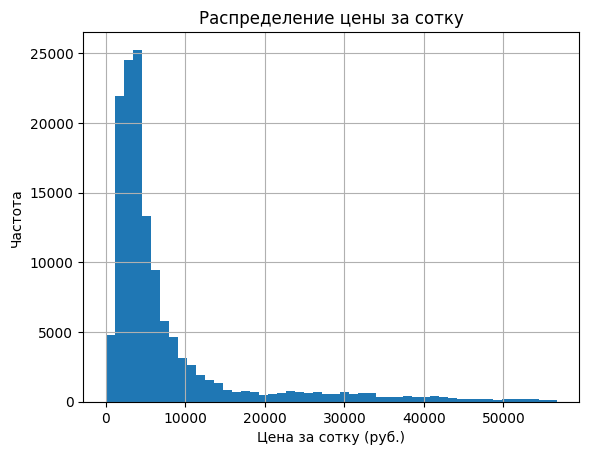

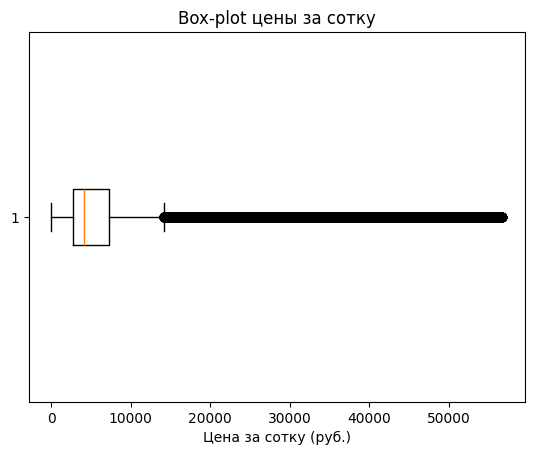

In [30]:
import numpy as np
import matplotlib.pyplot as plt


# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_sqm"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["land_value_per_sqm"] <= p99].copy()

print(blocks_clean["land_value_per_sqm"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_sqm"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["land_value_per_sqm"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()


In [34]:

# удалить несколько колонок
blocks_clean = blocks_clean.drop(columns=["cadastralDistrictsCode", "readable_address", "cost_value", "cost_index",
"land_record_category_type", "permitted_use_established_by_document","specified_area","log_cost_index", 'count'])


In [35]:
blocks_clean.columns.to_list()

['geometry',
 'residential',
 'business',
 'recreation',
 'industrial',
 'transport',
 'special',
 'agriculture',
 'land_use',
 'share',
 'is_living',
 'number_of_floors',
 'footprint_area',
 'build_floor_area',
 'living_area',
 'non_living_area',
 'population',
 'site_area',
 'fsi',
 'gsi',
 'mxi',
 'l',
 'osr',
 'share_living',
 'share_non_living',
 'morphotype',
 'area_accessibility',
 'land_value',
 'land_value_per_sqm',
 'log_land_value',
 'log_land_value_per_sqm']

In [ ]:
# blocks_clean.to_file("../data/blocks_clean.geojson", driver="GeoJSON")


In [ ]:
import pandas as pd

# 1. Отбираем числовые столбцы и фильтруем
num = blocks_clean.select_dtypes(include=['number'])
num = num[num['land_value'] > 1]

# 2. Считаем count + статистики
agg_stats = num.agg(['count', 'min', 'max', 'mean', 'median', 'std']).T

# 3. Переименовываем столбцы
agg_stats.index.name = 'Variable'
agg_stats = agg_stats.rename(columns={
    'count':  'Count',
    'min':    'Min',
    'max':    'Max',
    'mean':   'Mean',
    'median': 'Median',
    'std':    'SD'
})

# 4. Приводим Count к int
agg_stats['Count'] = agg_stats['Count'].astype(int)

# 5. Округляем остальные метрики
for col in ['Min','Max','Mean','Median','SD']:
    agg_stats[col] = agg_stats[col].round(2)

# 6. Настраиваем глобальный формат для float
pd.options.display.float_format = '{:,.2f}'.format

# 7. Показываем результат
agg_stats


,Count,Min,Max,Mean,Median,SD
Variable,,,,,,
cadastralDistrictsCode,137245,78.00,78.00,78.00,78.00,0.00
cost_value,137245,"1,804.00","26,651,128,642.65","32,740,653.62","5,202,532.90","170,332,178.98"
cost_index,137245,0.00,"25,431,450.90","8,245.05","4,108.01","69,527.20"
specified_area,137245,2.00,"13,700,838.00","7,450.87","1,173.00","74,213.72"
residential,137245,0.00,1.00,0.73,1.00,0.44
business,137245,0.00,1.00,0.02,0.00,0.13
recreation,137245,0.00,1.00,0.09,0.00,0.28
industrial,137245,0.00,1.00,0.06,0.00,0.24
transport,137245,0.00,1.17,0.09,0.00,0.27


/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_8359/3918900748.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w1 = libpysal.weights.Queen.from_dataframe(blocks_default)
/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 224 disconnected components.
 There are 193 islands with ids: 145, 365, 366, 495, 929, 1244, 1405, 1420, 1440, 1894, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 2566, 2597, 3272, 3273, 3274, 3275, 3276, 3277, 3278, 3292, 3293, 3294, 3295, 3296, 3297, 3298, 3322, 3323, 3324, 3325, 3326, 3327, 3328, 3329, 3330, 3331, 3332, 3340, 3341, 3342, 3358, 3359, 3360, 3361, 3362, 3363, 3364, 3365, 3366, 3367, 3368, 3406, 3407, 3408, 3409, 3410, 3411, 3417, 3439, 3504, 3763, 3774, 3775, 3883, 3891, 3893, 4027, 4

('WARNING: ', 145, ' is an island (no neighbors)')
('WARNING: ', 365, ' is an island (no neighbors)')
('WARNING: ', 366, ' is an island (no neighbors)')
('WARNING: ', 495, ' is an island (no neighbors)')
('WARNING: ', 929, ' is an island (no neighbors)')
('WARNING: ', 1244, ' is an island (no neighbors)')
('WARNING: ', 1405, ' is an island (no neighbors)')
('WARNING: ', 1420, ' is an island (no neighbors)')
('WARNING: ', 1440, ' is an island (no neighbors)')
('WARNING: ', 1894, ' is an island (no neighbors)')
('WARNING: ', 1934, ' is an island (no neighbors)')
('WARNING: ', 1935, ' is an island (no neighbors)')
('WARNING: ', 1936, ' is an island (no neighbors)')
('WARNING: ', 1937, ' is an island (no neighbors)')
('WARNING: ', 1938, ' is an island (no neighbors)')
('WARNING: ', 1939, ' is an island (no neighbors)')
('WARNING: ', 1940, ' is an island (no neighbors)')
('WARNING: ', 1941, ' is an island (no neighbors)')
('WARNING: ', 1942, ' is an island (no neighbors)')
('WARNING: ', 194

/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/esda/moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


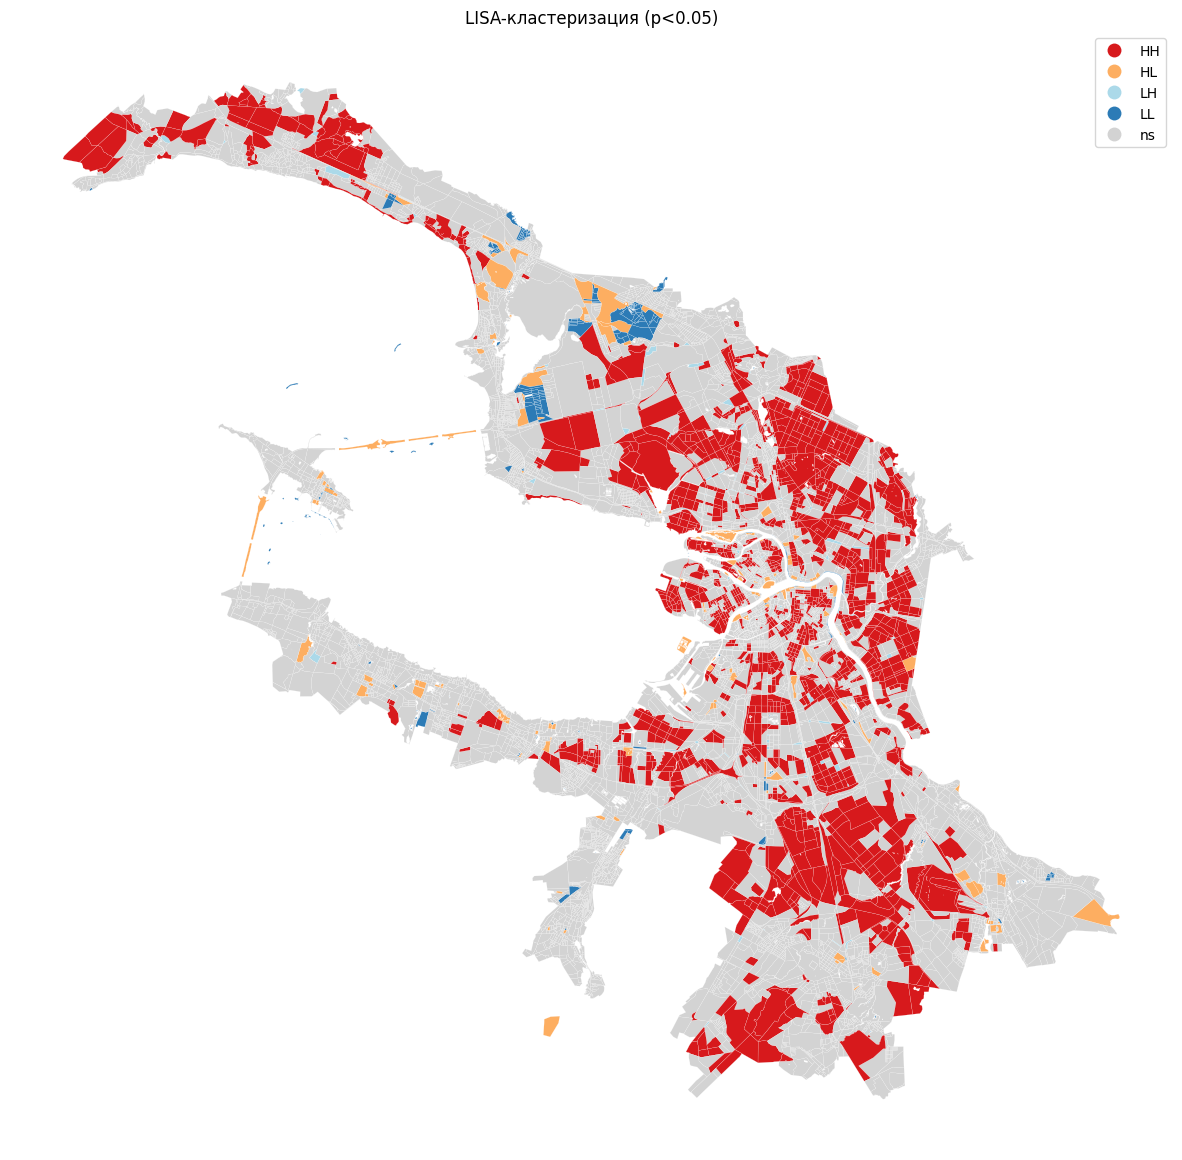

In [34]:
import libpysal
from esda.moran import Moran, Moran_Local
import matplotlib.pyplot as plt
from splot.esda import lisa_cluster

# 1) Подготовка: spatial weights
# Если у вас уже есть w1 (Rook или Queen), используем его, иначе:
w1 = libpysal.weights.Queen.from_dataframe(blocks_default)
# или: w1 = libpysal.weights.Rook.from_dataframe(blocks)
w1.transform = 'r'   # row-standardization

# 2) Извлекаем вектор переменной
y = blocks_default['log_total_price'].values

# 3) Глобальный индекс Морена
moran_global = Moran(y, w1)
print("Global Moran’s I:",     round(moran_global.I,3))
print("p-value (normal):",     round(moran_global.p_norm,3))
print("z-score (normal):",     round(moran_global.z_norm,3))
print("p-value (permut.):",    round(moran_global.p_sim,3))
print("z-score (permut.):",    round(moran_global.z_sim,3))

# 4) Локальный индекс Морена
lisa = Moran_Local(y, w1)

# 5) Добавляем результаты в GeoDataFrame
blocks_default['lisa_I']   = lisa.Is          # локальные значения I
blocks_default['lisa_p']   = lisa.p_sim       # p-values по перестановкам
blocks_default['lisa_q']   = lisa.q           # квадранты (1=HH, 2=LH, 3=LL, 4=HL)
blocks_default['lisa_sig'] = lisa.p_sim < 0.05

# 6) Визуализация LISA-кластеров
fig, ax = plt.subplots(1, figsize=(15, 15))
# splot умеет сам раскрасить по четырём кластерам
lisa_cluster(lisa, blocks_default, p=0.05, ax=ax)
ax.set_title("LISA-кластеризация (p<0.05)")
ax.axis('off')
plt.show()
